<a href="https://colab.research.google.com/github/likithargowda121/ml-day1-iris-classification/blob/main/Day1_MLP_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Iris Flower Classification using Neural Networks
# Objective

The objective of this project is to classify iris flower species using a neural network model (MLPClassifier) and analyze feature relationships through data visualization.

1.Import Libraries

In [84]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

2.Load Dataset

In [85]:
iris = load_iris()

df = pd.DataFrame(iris.data, columns=iris.feature_names)

df['target'] = iris.target

df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


3.Explore the Data

In [86]:
print("data set information:\n",df.info())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   sepal length (cm)  150 non-null    float64
 1   sepal width (cm)   150 non-null    float64
 2   petal length (cm)  150 non-null    float64
 3   petal width (cm)   150 non-null    float64
 4   target             150 non-null    int64  
dtypes: float64(4), int64(1)
memory usage: 6.0 KB
data set information:
 None


In [87]:
print("used of described():\n",df.describe())


used of described():
        sepal length (cm)  sepal width (cm)  petal length (cm)  \
count         150.000000        150.000000         150.000000   
mean            5.843333          3.057333           3.758000   
std             0.828066          0.435866           1.765298   
min             4.300000          2.000000           1.000000   
25%             5.100000          2.800000           1.600000   
50%             5.800000          3.000000           4.350000   
75%             6.400000          3.300000           5.100000   
max             7.900000          4.400000           6.900000   

       petal width (cm)      target  
count        150.000000  150.000000  
mean           1.199333    1.000000  
std            0.762238    0.819232  
min            0.100000    0.000000  
25%            0.300000    0.000000  
50%            1.300000    1.000000  
75%            1.800000    2.000000  
max            2.500000    2.000000  


In [88]:
print("used of shape():\n",df.shape)

used of shape():
 (150, 5)


In [89]:
print("used of isnull():\n",df.isnull().sum())

used of isnull():
 sepal length (cm)    0
sepal width (cm)     0
petal length (cm)    0
petal width (cm)     0
target               0
dtype: int64


### Observations from Data Exploration

Based on the `df.info()`, `df.describe()`, `df.shape`, and `df.isnull().sum()` outputs, here are my key observations about the Iris dataset:

1.  **Dataset Size:** The dataset contains 150 entries (rows) and 5 columns (features plus the target).
2.  **Data Types:** All feature columns (`sepal length (cm)`, `sepal width (cm)`, `petal length (cm)`, `petal width (cm)`) are of `float64` type, while the `target` column is `int64`.
3.  **Missing Values:** There are no missing values in any of the columns, as indicated by `df.isnull().sum()` showing all zeros.
4.  **Statistical Summary (`df.describe()`):**
    *   **Count:** All columns have 150 non-null entries, confirming no missing data.
    *   **Mean:** Provides the average value for each feature. For example, the average 'sepal length (cm)' is approximately 5.84 cm.
    *   **Standard Deviation (std):** Indicates the spread of the data around the mean. 'Petal length (cm)' has the largest standard deviation, suggesting more variability.
    *   **Min/Max:** Shows the minimum and maximum values for each feature.
    *   **25%, 50% (Median), 75% Quartiles:** These values give insight into the distribution of the data, helping to identify potential skewness or outliers.
        *   For instance, the median 'sepal length (cm)' is 5.8 cm, which is close to its mean, suggesting a relatively symmetric distribution for this feature.
        *   The `target` column has values ranging from 0 to 2, with a mean of 1, confirming the three classes of Iris species are present.


---



4.Create 5 Charts

Chart 1 — Pairplot

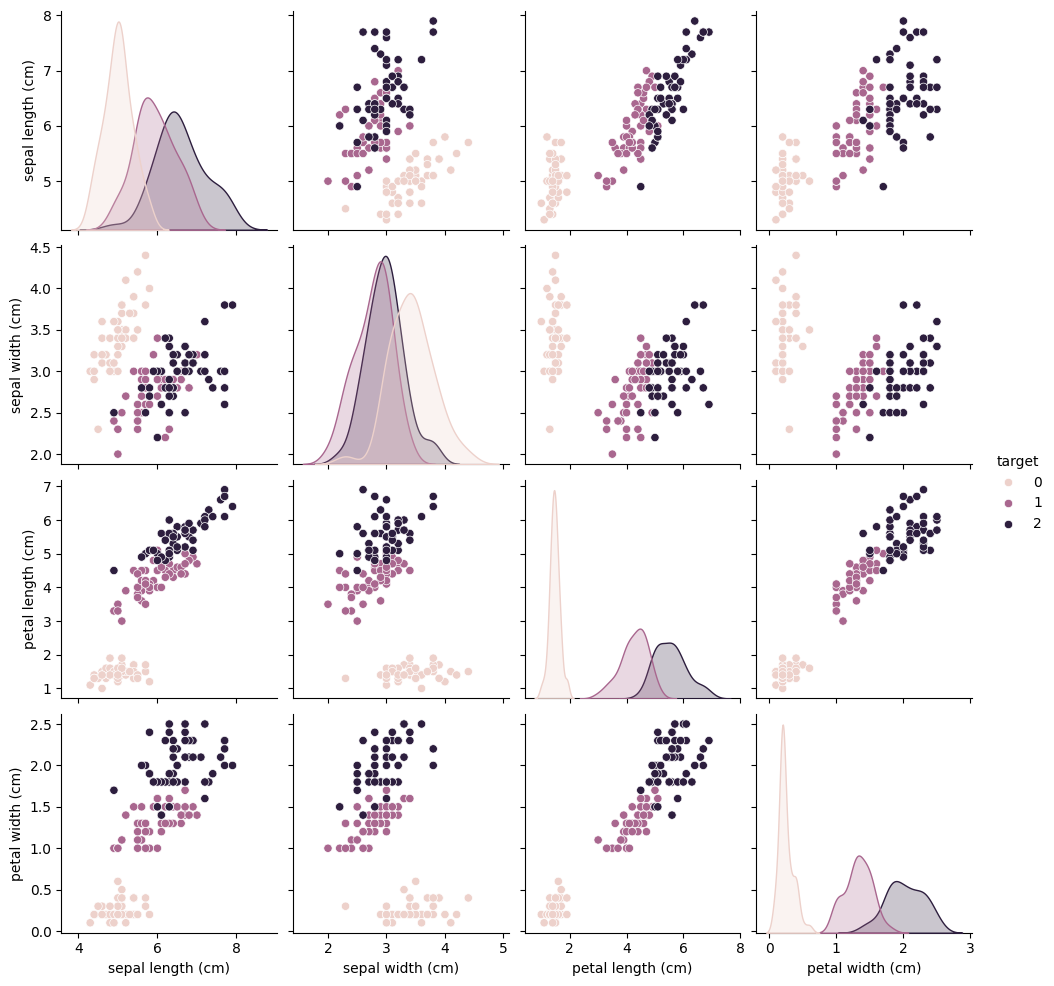

In [90]:
sns.pairplot(df, hue='target')
plt.show()


Observation:

Some flower classes are clearly separable based on petal length and width.

---



Chart 2 — Heatmap

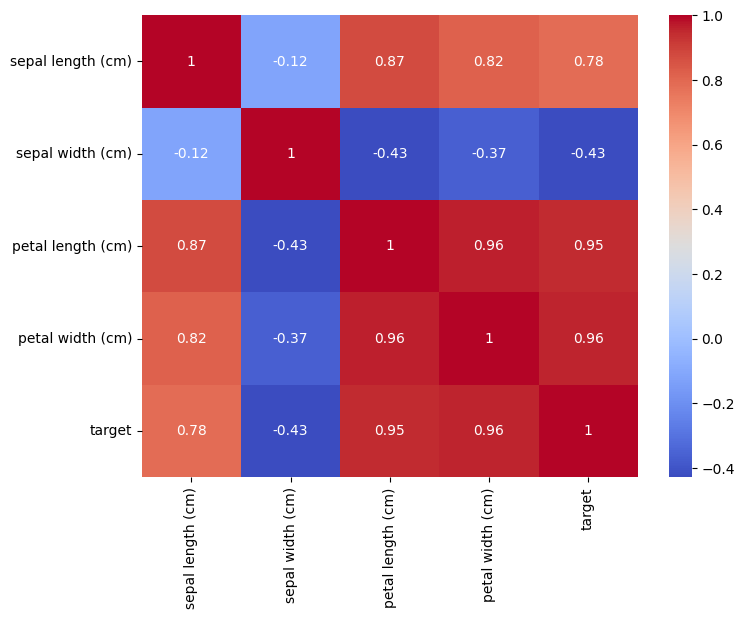

In [91]:
plt.figure(figsize=(8,6))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.show()

Observation:

Petal length and petal width are highly correlated.

---



Chart 3 — Boxplot

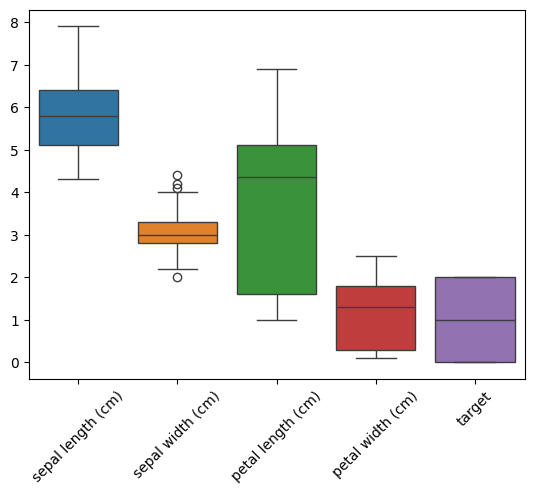

In [92]:
sns.boxplot(data=df)
plt.xticks(rotation=45)
plt.show()

Observation:

Most features have a balanced distribution with few outliers.

---



Chart 4 — Histogram

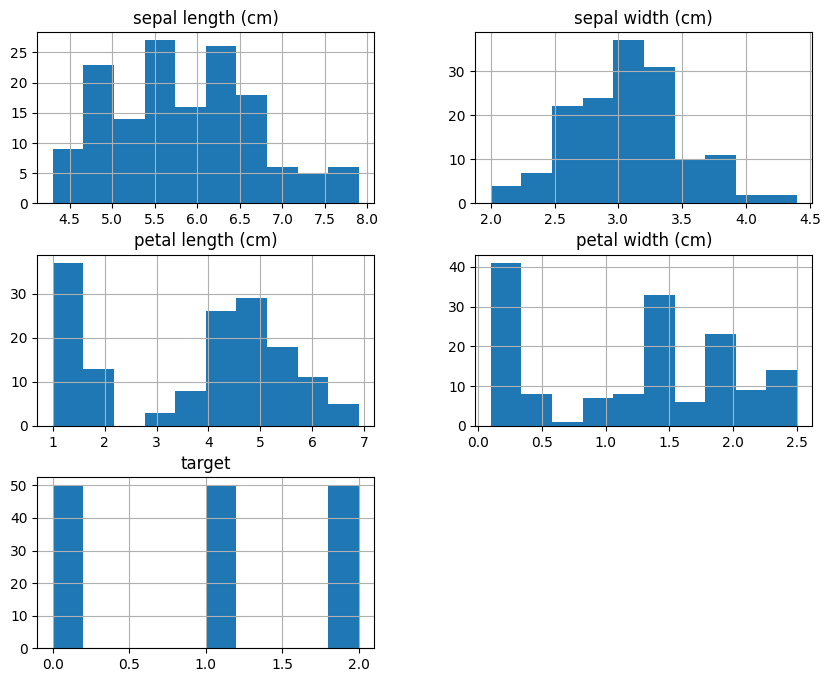

In [93]:
df.hist(figsize=(10,8))
plt.show()

Observation:

Feature values follow different distributions across measurements.

---



Chart 5 — Countplot

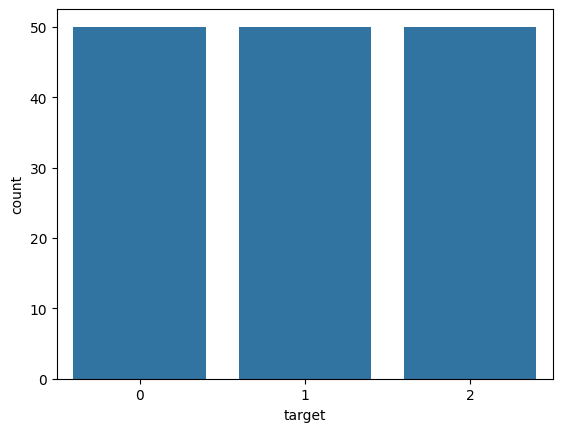

In [94]:
sns.countplot(x='target', data=df)
plt.show()

5.Split Features and Target

In [95]:
X = df.drop('target', axis=1)

y = df['target']

6.Train Test Split

In [96]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

7.Scale the Data

In [97]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)

X_test = scaler.transform(X_test)

1)fit_transform() -ONLY on training data
2)transform() -on test data

---



8.Build the MLP Model

In [98]:
model = MLPClassifier(
    hidden_layer_sizes=(10,10),
    max_iter=1000,
    random_state=42
)

model.fit(X_train, y_train)

MLPClassifier(hidden_layer_sizes=(10, 10), max_iter=1000, random_state=42)

9.Make Predictions

In [99]:
y_pred = model.predict(X_test)

10.Evaluate Model

Accuracy

In [100]:
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

Accuracy: 0.9666666666666667


Classification Report

In [101]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       1.00      0.89      0.94         9
           2       0.92      1.00      0.96        11

    accuracy                           0.97        30
   macro avg       0.97      0.96      0.97        30
weighted avg       0.97      0.97      0.97        30



Confusion Matrix

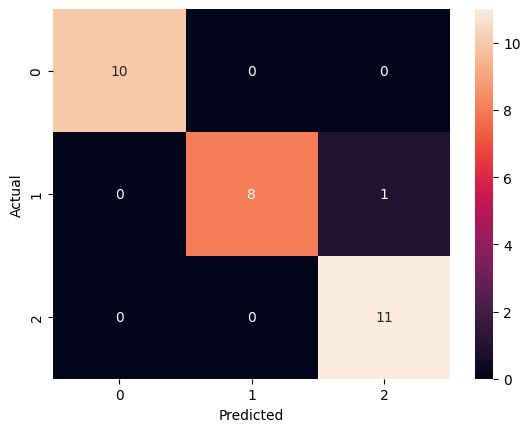

In [102]:
cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt='d')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

"The most surprising thing I found in this data was how clearly petal features separate the flower species."